# Import and setup

In [1]:
from pynamicalsys import HamiltonianSystem as HS
from pynamicalsys import PlotStyler

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
HS.available_models()

['henon heiles']

In [4]:
HS.available_integrators()

['svy4', 'vv2', 'imp']

In [35]:
path_figures = "../images"

# Quickstart

In [6]:
hs = HS(model="henon heiles")

In [8]:
num_ic = 100
dof = 2
q = np.zeros((num_ic, dof))
p = np.zeros((num_ic, dof))
E_ref = 1 / 8  # Total energy of the system
x = 0  # Define the initial condition
y_range = (-0.5, 0.5)
py_range = (-0.5, 0.5)

np.random.seed(13)
for i in range(num_ic):
    while True:
        py = np.random.uniform(*py_range)
        y = np.random.uniform(*y_range)
        px = 2 * (E_ref - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2
        if px > 0:
            q[i] = [x, y]
            p[i] = [np.sqrt(px), py]
            break
num_intersections = 10000
time_step = 0.01

In [9]:
hs.integrator("vv2", time_step=time_step)
q0 = q.copy()
p0 = p.copy()
PS_vv2 = hs.poincare_section(q0, p0, num_intersections)

In [10]:
hs.integrator("svy4", time_step=time_step)
q0 = q.copy()
p0 = p.copy()
PS_svy4 = hs.poincare_section(q0, p0, num_intersections)

In [11]:
hs.integrator("imp", time_step=time_step)
q0 = q.copy()
p0 = p.copy()
PS_imp = hs.poincare_section(q0, p0, num_intersections)

<Figure size 640x480 with 0 Axes>

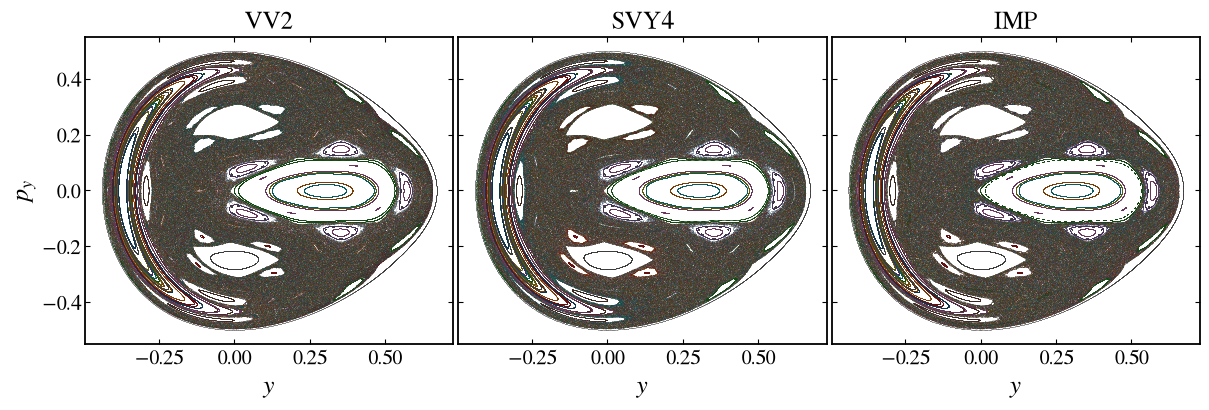

In [15]:
fontsize = 18
ps = PlotStyler(fontsize=fontsize, markersize=0.25, markeredgewidth=0)
ps.apply_style()

colors = sns.color_palette("tab10", num_ic)
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 4))

for i in range(num_ic):
    ax[0].plot(PS_vv2[i, :, 2], PS_vv2[i, :, 4], "o", c=colors[i])
    ax[1].plot(PS_svy4[i, :, 2], PS_svy4[i, :, 4], "o", c=colors[i])
    ax[2].plot(PS_imp[i, :, 2], PS_imp[i, :, 4], "o", c=colors[i])

ax[0].set_xlabel("$y$")
ax[0].set_ylabel("$p_y$")
ax[0].set_title("VV2", fontsize=fontsize)
ax[1].set_xlabel("$y$")
ax[1].set_title("SVY4", fontsize=fontsize)
ax[2].set_xlabel("$y$")
ax[2].set_title("IMP", fontsize=fontsize)


plt.tight_layout(pad=0.2)
plt.savefig(f"{path_figures}/henon_heiles_poincare_section.png", dpi=400)

# Trajectories

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import PlotStyler
from pynamicalsys import ContinuousDynamicalSystem as cds
from pynamicalsys import HamiltonianSystem as hs

In [2]:
time_step = 0.01

In [5]:
ds = cds(model="henon heiles")

In [ ]:
# Using RK4 integrator
ds.integrator("rk4", time_step=time_step)

# Total energy of the system
E = 1 / 8 

# Total integration time
total_time = 10000

# Initial condition
x = 0
y = 0.1
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)
u = np.array([x, y, px, py])

In [9]:
traj_rk4 = ds.trajectory(u, total_time)

In [10]:
ds = hs(model="henon heiles")

In [ ]:
# Using VV2 integrator
ds.integrator("vv2", time_step=time_step)

# Total energy of the system
E = 1 / 8 

# Total integration time
total_time = 10000

# Initial condition
x = 0
y = 0.1
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)
q = np.array([x, y])
p = np.array([px, py])

In [14]:
traj_vv2 = ds.trajectory(q, p, total_time)

In [42]:
traj_vv2.shape

(1000001, 5)

In [15]:
# Using svy4 integrator
ds.integrator("svy4", time_step=time_step)

# Total energy of the system
E = 1 / 8 

# Total integration time
total_time = 10000

# Initial condition
x = 0
y = 0.1
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)
q = np.array([x, y])
p = np.array([px, py])

In [16]:
traj_svy4 = ds.trajectory(q, p, total_time)

In [17]:
# Using imp integrator
ds.integrator("imp", time_step=time_step)

# Total energy of the system
E = 1 / 8 

# Total integration time
total_time = 10000

# Initial condition
x = 0
y = 0.1
py = 0
px = np.sqrt(2 * (E - x**2 * y + y**3 / 3) - x**2 - y**2 - py**2)
q = np.array([x, y])
p = np.array([px, py])

In [18]:
traj_imp = ds.trajectory(q, p, total_time)

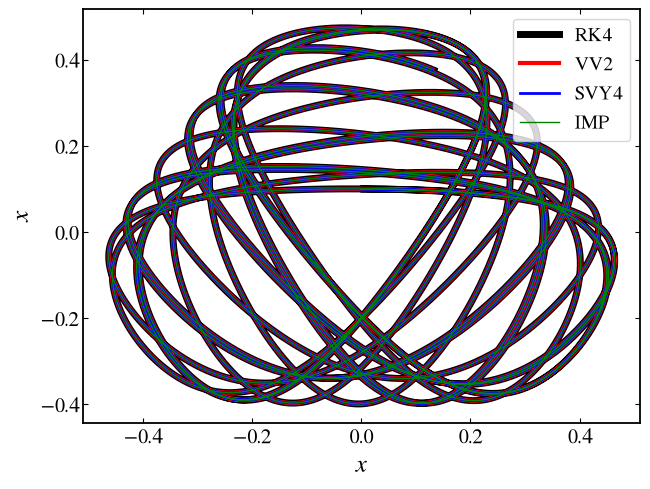

In [46]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

points_to_plot = 10000
plt.plot(traj_rk4[:points_to_plot, 1], traj_rk4[:points_to_plot, 2], "k", lw=5, label="RK4")
plt.plot(traj_vv2[:points_to_plot, 1], traj_vv2[:points_to_plot, 2], "r", lw=3, label="VV2")
plt.plot(traj_svy4[:points_to_plot, 1], traj_svy4[:points_to_plot, 2], "b", lw=2, label="SVY4")
plt.plot(traj_imp[:points_to_plot, 1], traj_imp[:points_to_plot, 2], "g", lw=1, label="IMP")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$x$")

plt.tight_layout(pad=0.2)
plt.savefig(f"{path_figures}/henon_heiles_trajectory.png", dpi=400)

In [28]:
def total_energy(q, p):
    V = 0.5 * (q[0] * q[0] + q[1] * q[1]) + q[0] * q[0] * q[1] - q[1] * q[1] * q[1] / 3.0
    T = 0.5 * (p[0] ** 2 + p[1] ** 2)

    return T + V

In [29]:
Et = np.zeros((traj_rk4.shape[0] - 1, 5))
for i in range(Et.shape[0]):
    Et[i, 0] = traj_rk4[i + 1, 0]

    q = traj_rk4[i, 1: dof + 1]
    p = traj_rk4[i, dof + 1:]
    Et[i, 1] = total_energy(q, p)

    q = traj_vv2[i + 1, 1: dof + 1]
    p = traj_vv2[i + 1, dof + 1:]
    Et[i, 2] = total_energy(q, p)

    q = traj_svy4[i + 1, 1: dof + 1]
    p = traj_svy4[i + 1, dof + 1:]
    Et[i, 3] = total_energy(q, p)

    q = traj_imp[i + 1, 1: dof + 1]
    p = traj_imp[i + 1, dof + 1:]
    Et[i, 4] = total_energy(q, p)

<Figure size 640x480 with 0 Axes>

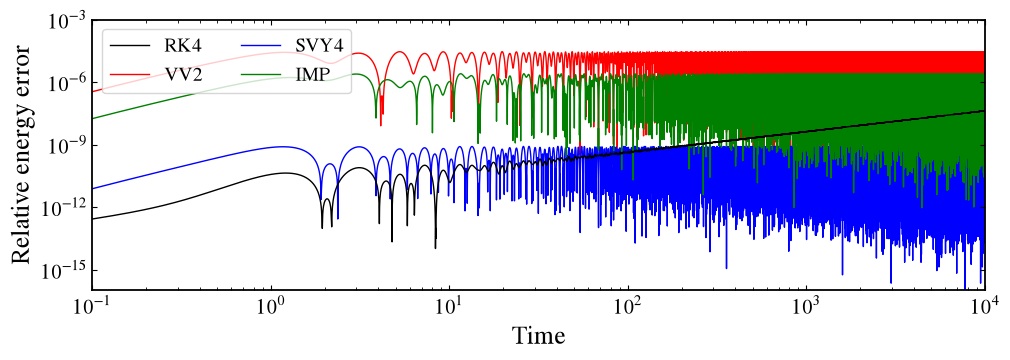

In [47]:
ps = PlotStyler(fontsize=18)
ps.apply_style()

fig, ax = plt.subplots(figsize=(10, 3.5))
plt.plot(Et[:, 0], abs(Et[:, 1] - E)/E, "k", label="RK4", zorder=2)
plt.plot(Et[:, 0], abs(Et[:, 2] - E)/E, "r", label="VV2", zorder=0)
plt.plot(Et[:, 0], abs(Et[:, 3] - E)/E, "b", label="SVY4", zorder=0)
plt.plot(Et[:, 0], abs(Et[:, 4] - E)/E, "g", label="IMP", zorder=1)

plt.legend(loc="upper left", ncol=2)
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-16, 1e-3)
plt.xlim(1e-1, 1e4)
plt.xlabel("Time")
plt.ylabel("Relative energy error")

plt.tight_layout(pad=0.2)
plt.savefig(f"{path_figures}/henon_heiles_energy_check.png", dpi=400)